Датасеты:


*   [data_01.csv](https://drive.google.com/file/d/1a9MsoRtCsDJnVtSfXCLtoc5fIQtr5Mc6/view?usp=sharing)
*   [data_02.csv](https://drive.google.com/file/d/1wgJwNocOtiGmCfNeD0US4Ufy7d5ImrQw/view?usp=sharing)
*   [data_03.csv](https://drive.google.com/file/d/1MXWLFV4lIzW2hYc75sQi2IRWWzZYjOIT/view?usp=sharing)
*   [data_04.csv](https://drive.google.com/file/d/1dy0qodzR8GjT3xaW-w46FiHdcvGH5DKt/view?usp=sharing)



In [1]:
import pandas as pd
import numpy as np
try:
    from geopy.distance import geodesic
except ModuleNotFoundError:
    %pip install geopy
    from geopy.distance import geodesic

print(pd.read_csv('data_01.csv'))

           lat        lon   timestamp
0    55.641644  37.360168  1715115606
1    55.641644  37.360168  1715115756
2    55.641644  37.360168  1715115906
3    55.641644  37.360168  1715116056
4    55.641644  37.360168  1715116206
..         ...        ...         ...
125  55.641644  37.360168  1715134377
126  55.641644  37.360168  1715134527
127  55.641644  37.360168  1715134677
128  55.641644  37.360168  1715134828
129  55.641644  37.360168  1715134978

[130 rows x 3 columns]


Есть три столбца:


*   lat - широта
*   lon - долгота
*   timestamp - время в формате [timestamp](https://timestamp.online/)

Задачи:

1.   Расстояние между точками (столбец distant)
2.   Скорость между точками (столбец speed)
3.   Направление движения в градусах (столбец direction):

*   0° - движение на север
*   90° - движение на восток
*   180° - движение на юг
*   270° - движение на запад


4.   Сокращенный анализ датафрейма (Миниму 4 параметра):
*   Средняя скорость
*   Максимальная скорость




# Задача 1

Расстояние между точками (столбец distant)

In [2]:
# Создадим датафреймы по всем данным и соберём все эти данные в список
# Сразу отсортируем по временной метке, чтобы не допустить в дальнейшем каких-то проблем
data = []
for i in range(1, 5):
    data.append(pd.read_csv(f'data_0{i}.csv'))
    data[i - 1] = data[i - 1].sort_values(by='timestamp', ascending=True)
    data[i - 1].dropna(inplace=True)
    data[i - 1].reset_index(drop=True, inplace=True)
print(data)
data[0]

[           lat        lon   timestamp
0    55.641644  37.360168  1715115606
1    55.641644  37.360168  1715115756
2    55.641644  37.360168  1715115906
3    55.641644  37.360168  1715116056
4    55.641644  37.360168  1715116206
..         ...        ...         ...
125  55.641644  37.360168  1715134377
126  55.641644  37.360168  1715134527
127  55.641644  37.360168  1715134677
128  55.641644  37.360168  1715134828
129  55.641644  37.360168  1715134978

[130 rows x 3 columns],            lat        lon   timestamp
0    55.714977  37.314159  1746791112
1    55.714977  37.314159  1746791118
2    55.714977  37.314159  1746791121
3    55.714977  37.314159  1746791125
4    55.714977  37.314159  1746791138
..         ...        ...         ...
579  55.799892  37.392681  1746809012
580  55.799831  37.392948  1746809014
581  55.799770  37.393135  1746809016
582  55.799717  37.393215  1746809018
583  55.799740  37.393120  1746809058

[584 rows x 3 columns],            lat        lon   timestamp

,lat,lon,timestamp
0,55.641644,37.360168,1715115606
1,55.641644,37.360168,1715115756
2,55.641644,37.360168,1715115906
3,55.641644,37.360168,1715116056
4,55.641644,37.360168,1715116206
...,...,...,...
125,55.641644,37.360168,1715134377
126,55.641644,37.360168,1715134527
127,55.641644,37.360168,1715134677
128,55.641644,37.360168,1715134828


Расстояние между точками можно вычислить следующим образом:
- Находим меридианальное расстояние между двумя точками, умножив разницу в широте в градусах на 111,16 км, А.
- Находим расстояние по параллели точки с меньшей широтой, умножив разность долгот в градусах на 111,3 км и косинус точки с меньшей широтой, B.
- Находим искомое расстояние по теореме Пифагора в варианте для сферической поверхности как

$$(C/R)^2 =(A/R)^2+(B/R)^2$$
, где $R = 6400 км$ - радиус Земли.

In [3]:
r = 6400

def dist(lat2, lat1, long2, long1):
    dist_r = abs(lat1 - lat2) * 111.16
    dist_z = abs(long1 - long2) * np.cos(min(abs(long1), abs(long2)) * np.pi / 180) * 111.3
    dist_f = ((dist_r / r) ** 2 + (dist_z / r) ** 2) ** 0.5 * r
    return dist_f

In [4]:
for i in data:
    i['distant'] = 0.0
    for j in range(1, i.shape[0]):
        i.loc[j, 'distant'] = dist(i.loc[j, 'lat'], i.loc[j - 1, 'lat'], i.loc[j, 'lon'], i.loc[j - 1, 'lon'])

# Задача 2
Скорость между точками (столбец speed)

Теперь так как мы выясниили расстояние между точками, по разнице во времени мы сможем вычислить скорость

Создадим столбец со временем из `timestamp`

In [5]:
for i in data:
    i['time'] = pd.to_datetime(i['timestamp'] * 1e9)

Теперь мы можем разделить расстояние, полученное в задаче №1 на время (`timedelta`) и получить скорость

In [6]:
import datetime as dt

In [7]:
data[1]

,lat,lon,timestamp,distant,time
0,55.714977,37.314159,1746791112,0.000000,2025-05-09 11:45:12
1,55.714977,37.314159,1746791118,0.000000,2025-05-09 11:45:18
2,55.714977,37.314159,1746791121,0.000000,2025-05-09 11:45:21
3,55.714977,37.314159,1746791125,0.000000,2025-05-09 11:45:25
4,55.714977,37.314159,1746791138,0.000000,2025-05-09 11:45:38
...,...,...,...,...,...
579,55.799892,37.392681,1746809012,0.145459,2025-05-09 16:43:32
580,55.799831,37.392948,1746809014,0.024568,2025-05-09 16:43:34
581,55.799770,37.393135,1746809016,0.017867,2025-05-09 16:43:36
582,55.799717,37.393215,1746809018,0.009242,2025-05-09 16:43:38


In [8]:
for i in data:
    i['speed'] = 0.0
    i['hours'] = 0.0
    for j in range(1, i.shape[0]):
        i.loc[j, 'hours'] = (i.loc[j, 'time'] - i.loc[j - 1, 'time']).seconds / 3600.0
    i['speed'] = i['distant'] / i['hours']

In [9]:
data[1]

,lat,lon,timestamp,distant,time,speed,hours
0,55.714977,37.314159,1746791112,0.000000,2025-05-09 11:45:12,NaN,0.000000
1,55.714977,37.314159,1746791118,0.000000,2025-05-09 11:45:18,0.000000,0.001667
2,55.714977,37.314159,1746791121,0.000000,2025-05-09 11:45:21,0.000000,0.000833
3,55.714977,37.314159,1746791125,0.000000,2025-05-09 11:45:25,0.000000,0.001111
4,55.714977,37.314159,1746791138,0.000000,2025-05-09 11:45:38,0.000000,0.003611
...,...,...,...,...,...,...,...
579,55.799892,37.392681,1746809012,0.145459,2025-05-09 16:43:32,58.183729,0.002500
580,55.799831,37.392948,1746809014,0.024568,2025-05-09 16:43:34,44.222315,0.000556
581,55.799770,37.393135,1746809016,0.017867,2025-05-09 16:43:36,32.160643,0.000556
582,55.799717,37.393215,1746809018,0.009242,2025-05-09 16:43:38,16.636340,0.000556


Скорость в данном случае получаем в километрах в час

# Задача 3
Направление движения в градусах (столбец direction):

*   0° - движение на север
*   90° - движение на восток
*   180° - движение на юг
*   270° - движение на запад

 Фактически надо вычислить азимут

In [10]:
for i in data:
    i['bearing'] = 0.0
    i['direction'] = ''

In [11]:
def bearing(lat2, lat1, long2, long1):
    lat1_rad = lat1 * np.pi / 180
    lat2_rad = lat2 * np.pi / 180
    long1_rad = long1 * np.pi / 180
    long2_rad = long2 * np.pi / 180
    dlong = long2_rad - long1_rad
    theta_rad = np.atan2(np.sin(dlong) * np.cos(lat2_rad), np.cos(lat1_rad) * np.sin(lat2_rad) - np.sin(lat1_rad) * np.cos(lat2_rad) * np.cos(dlong))
    theta = (theta_rad * 180 / np.pi + 360) % 360 
    if theta >= 225 and theta < 315:
        return theta, 'Запад'
    elif theta >= 45 and theta < 135:
        return theta, 'Восток'
    elif theta >= 135 and theta < 225:
        return theta, 'Юг'
    else:
        return theta, 'Север'

In [12]:
for i in data:
    for j in range(1, i.shape[0]):
        i.loc[j, 'bearing'], i.loc[j, 'direction'] = bearing(i.loc[j, 'lat'], i.loc[j - 1, 'lat'], i.loc[j, 'lon'], i.loc[j - 1, 'lon'])

In [13]:
data[1]

,lat,lon,timestamp,distant,time,speed,hours,bearing,direction
0,55.714977,37.314159,1746791112,0.000000,2025-05-09 11:45:12,NaN,0.000000,0.000000,
1,55.714977,37.314159,1746791118,0.000000,2025-05-09 11:45:18,0.000000,0.001667,0.000000,Север
2,55.714977,37.314159,1746791121,0.000000,2025-05-09 11:45:21,0.000000,0.000833,0.000000,Север
3,55.714977,37.314159,1746791125,0.000000,2025-05-09 11:45:25,0.000000,0.001111,0.000000,Север
4,55.714977,37.314159,1746791138,0.000000,2025-05-09 11:45:38,0.000000,0.003611,0.000000,Север
...,...,...,...,...,...,...,...,...,...
579,55.799892,37.392681,1746809012,0.145459,2025-05-09 16:43:32,58.183729,0.002500,103.646345,Восток
580,55.799831,37.392948,1746809014,0.024568,2025-05-09 16:43:34,44.222315,0.000556,112.128955,Восток
581,55.799770,37.393135,1746809016,0.017867,2025-05-09 16:43:36,32.160643,0.000556,120.153348,Восток
582,55.799717,37.393215,1746809018,0.009242,2025-05-09 16:43:38,16.636340,0.000556,139.864704,Юг


# Задача 4
Сокращенный анализ датафрейма (Минимум 4 параметра):
*   Средняя скорость
*   Максимальная скорость

Датасет data_01:


,lat,lon,timestamp,distant,time,speed,hours,bearing
count,130.000000,130.000000,1.300000e+02,130.0,130,129.0,130.000000,130.0
mean,55.641644,37.360168,1.715125e+09,0.0,2024-05-07 23:41:31.738461440,0.0,0.041393,0.0
min,55.641644,37.360168,1.715116e+09,0.0,2024-05-07 21:00:06,0.0,0.000000,0.0
25%,55.641644,37.360168,1.715120e+09,0.0,2024-05-07 22:20:48.500000,0.0,0.041667,0.0
50%,55.641644,37.360168,1.715125e+09,0.0,2024-05-07 23:41:32,0.0,0.041667,0.0
75%,55.641644,37.360168,1.715130e+09,0.0,2024-05-08 01:02:14.500000,0.0,0.041667,0.0
max,55.641644,37.360168,1.715135e+09,0.0,2024-05-08 02:22:58,0.0,0.041944,0.0
std,0.000000,0.000000,5.657201e+03,0.0,NaN,0.0,0.003660,0.0


Средняя скорость:  0.0  км/ч
Максимальная скорость:  0.0  км/ч


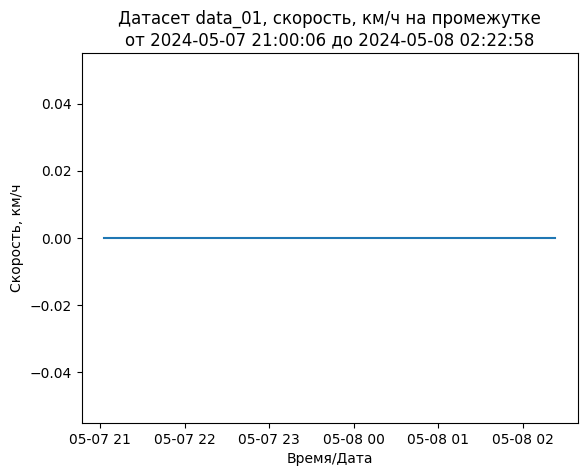

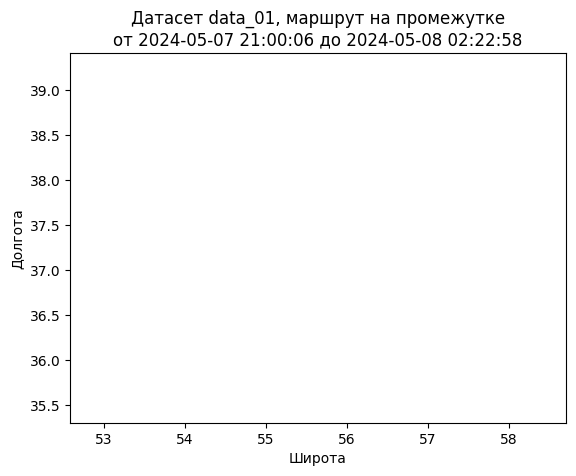

Датасет data_02:


,lat,lon,timestamp,distant,time,speed,hours,bearing
count,584.000000,584.000000,5.840000e+02,584.000000,584,580.000000,584.000000,584.000000
mean,55.746501,37.118531,1.746801e+09,0.344381,2025-05-09 14:28:29.785959168,169.457637,0.008536,162.650008
min,55.670174,36.884693,1.746791e+09,0.000000,2025-05-09 11:45:12,0.000000,0.000000,0.000000
25%,55.735111,37.039422,1.746793e+09,0.018694,2025-05-09 12:24:22.500000,30.184856,0.000556,79.906826
50%,55.746300,37.073172,1.746804e+09,0.115030,2025-05-09 15:16:07.500000,58.565537,0.001389,143.123321
75%,55.757707,37.165257,1.746808e+09,0.183017,2025-05-09 16:25:47,94.497301,0.003056,253.878815
max,55.960094,37.481915,1.746809e+09,35.384308,2025-05-09 16:44:18,56851.925398,1.159722,359.207484
std,0.032112,0.112350,6.727109e+03,2.150962,NaN,2359.671971,0.067790,104.612974


Средняя скорость:  169.4576367547367  км/ч
Максимальная скорость:  56851.92539808399  км/ч


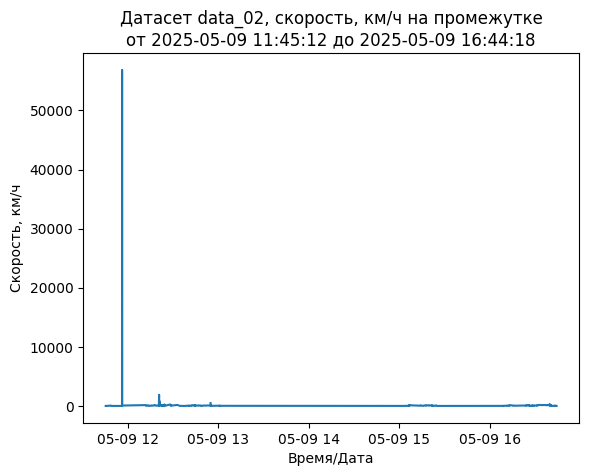

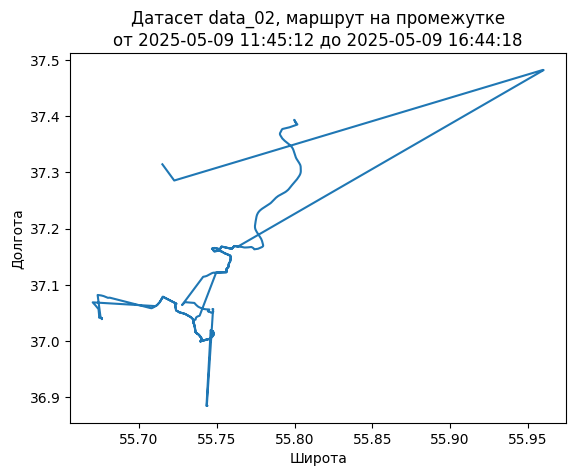

Датасет data_03:


,lat,lon,timestamp,distant,time,speed,hours,bearing
count,230.000000,230.000000,2.300000e+02,230.000000,230,229.000000,230.000000,230.000000
mean,55.766420,37.430025,1.747730e+09,0.238286,2025-05-20 08:32:37.439130880,46.219514,0.004676,173.141848
min,55.711937,37.381329,1.747727e+09,0.000000,2025-05-20 07:48:37,0.000000,0.000000,0.000000
25%,55.722326,37.401474,1.747730e+09,0.014738,2025-05-20 08:26:38.500000,19.960656,0.000833,98.976792
50%,55.750074,37.420607,1.747730e+09,0.046293,2025-05-20 08:38:35,37.320603,0.001667,193.640755
75%,55.803725,37.469373,1.747731e+09,0.140563,2025-05-20 08:47:58.249999872,63.185160,0.003611,226.490962
max,55.937305,37.493034,1.747731e+09,14.887888,2025-05-20 08:53:09,1128.970158,0.153611,357.520610
std,0.051082,0.036354,1.169917e+03,1.376434,NaN,77.031153,0.012314,85.202291


Средняя скорость:  46.219513641930355  км/ч
Максимальная скорость:  1128.970158065076  км/ч


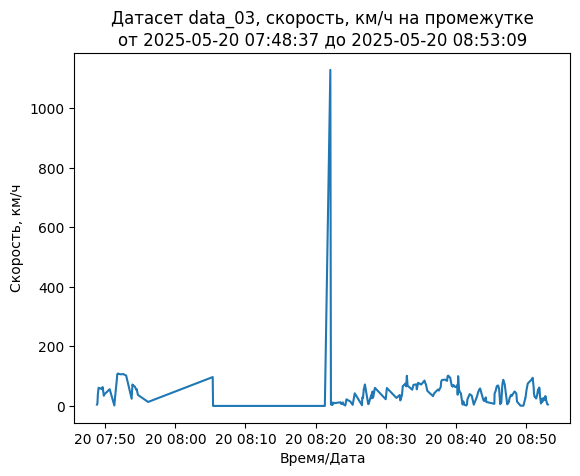

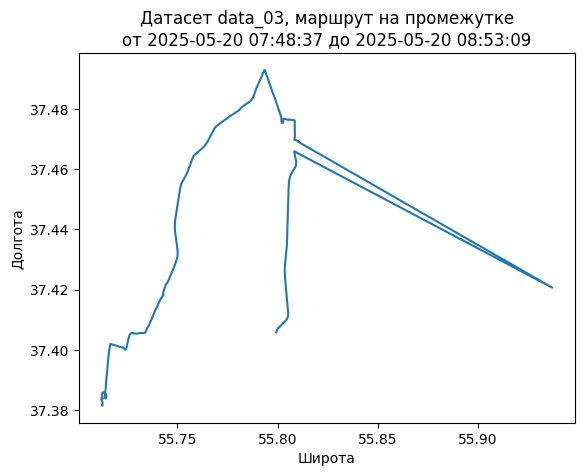

Датасет data_04:


/Users/muxa/Library/Python/3.9/lib/python/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,lat,lon,timestamp,distant,time,speed,hours,bearing
count,3653.000000,3653.000000,3.653000e+03,3653.000000,3653,3592.000000,3653.000000,3653.000000
mean,53.117761,49.972283,1.746513e+09,0.365627,2025-05-06 06:25:51.460717568,inf,0.003365,163.204115
min,53.095720,49.875970,1.746490e+09,0.000000,2025-05-06 00:00:02,0.000000,0.000000,0.000000
25%,53.104713,49.951100,1.746503e+09,0.152480,2025-05-06 03:36:31,98.859039,0.001667,64.915968
50%,53.117294,49.973610,1.746513e+09,0.388434,2025-05-06 06:32:21,103.620659,0.003889,159.317781
75%,53.130500,49.993020,1.746524e+09,0.410746,2025-05-06 09:25:22,108.373702,0.003889,259.267734
max,53.167717,50.045483,1.746534e+09,6.267780,2025-05-06 12:17:39,inf,0.012778,359.936774
std,0.013476,0.022567,1.256086e+04,0.441594,NaN,NaN,0.002166,111.095413


Средняя скорость:  inf  км/ч
Максимальная скорость:  inf  км/ч


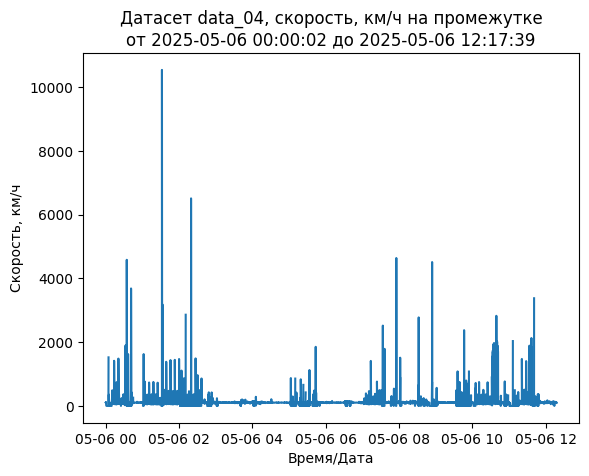

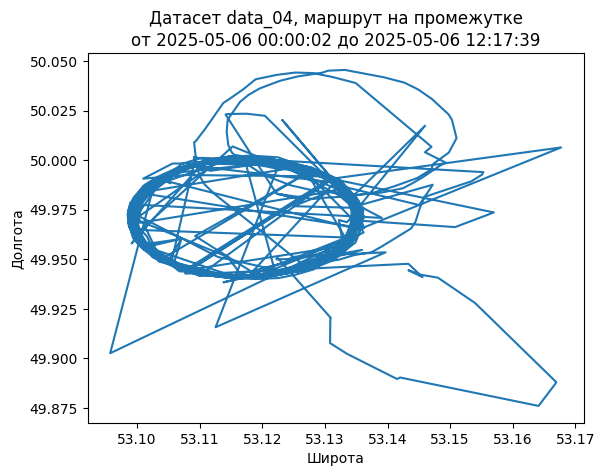

In [14]:
import matplotlib.pyplot as plt

for i in range(len(data)):
    print(f'Датасет data_0{i + 1}:')
    display(data[i].describe())
    print('Средняя скорость: ', data[i]['speed'].mean(), ' км/ч')
    print('Максимальная скорость: ', data[i]['speed'].max(), ' км/ч')
    plt.plot(data[i]['time'], data[i]['speed'])
    plt.title(f"Датасет data_0{i + 1}, скорость, км/ч на промежутке\nот {data[i]['time'].min()} до {data[i]['time'].max()}")
    plt.xlabel('Время/Дата')
    plt.ylabel('Скорость, км/ч')
    plt.show()
    plt.plot(data[i]['lat'], data[i]['lon'])
    plt.title(f"Датасет data_0{i + 1}, маршрут на промежутке\nот {data[i]['time'].min()} до {data[i]['time'].max()}")
    plt.xlabel('Широта')
    plt.ylabel('Долгота')
    plt.show()

По таким графикам можно чётко отследить моменты, когда происходит сбой системы GPS